# Deprivation and Urban Service Provision in London: A Borough-Level Analysis of Libraries and Pharmacies

Repo link:https://github.com/TanWANG41/London-service-provision-analysis.git

## 1. Introduction

The spatial distribution of everyday public services is important for understanding urban inequality. Access to local facilities is not only a matter of convenience, but also affects opportunities for learning, health support and participation in civic life. In this context, libraries and pharmacies are useful cases for examining variation in urban service provision. Public libraries are often regarded as part of a city’s social infrastructure, because beyond their traditional lending function, they also provide spaces for study, access to information and community use (Klinenberg, 2018). Community pharmacies, meanwhile, form an accessible part of primary care in England and are increasingly expected to support everyday health needs beyond hospitals and GP surgeries (Anderson and Sharma, 2020; Rutter and Barnes, 2024).

Deprivation offers one possible perspective for understanding these patterns. In England, the Index of Multiple Deprivation (IMD) is widely used to compare relative disadvantage between areas and combines information on income, employment, health, education, crime, housing and living environment (Ministry of Housing, Communities and Local Government, 2019). If deprivation is related to service provision, differences in deprivation may be reflected in differences in the level of facilities available across areas.

London provides a useful case study because its boroughs show clear differences in both deprivation and population size (Greater London Authority, n.d.). This makes it possible to compare local service provision across the city, while also examining whether deprivation helps explain those differences. Thus, this study explores whether borough-level deprivation is related to the distribution of library and pharmacy provision in London. The focus is not on assuming that deprivation determines where services are located, but on examining whether a clear relationship can be observed at borough level.

This study has three objectives:
1. to map the borough-level distribution of libraries and pharmacies across London. 
2. to compare provision after standardising by population.
3. to examine whether borough-level deprivation is associated with library and pharmacy provision per 100,000 residents.

## 2. Data and Methods

### 2.1 Data sources

The analysis combines four datasets: OpenStreetMap point data for libraries and pharmacies, London borough boundary data (Greater London Authority, n.d.), borough population data (Greater London Authority, n.d.), and the Index of Multiple Deprivation (IMD) (MHCLG GeoPortal, 2025). The OpenStreetMap datasets provide the facility locations, the borough boundaries define the spatial units of analysis, the population data allow provision to be standardised per 100,000 residents, and the IMD data provide the borough-level measure of deprivation.

### 2.2 Analytical approach

The analysis was carried out in two stages. First, descriptive analysis was used to map and summarise the borough-level distribution of libraries and pharmacies. This included tables and choropleth maps showing both absolute counts and population-standardised provision. These outputs provided an overview of spatial variation across London.

Second, borough-level patterns of deprivation and service provision were compared. A summary table ordered by deprivation was produced, followed by scatterplots comparing deprivation with libraries per 100,000 residents and pharmacies per 100,000 residents. Pearson correlation was then used to assess the strength and direction of the relationship, and simple linear regression was used to test whether deprivation was associated with borough-level provision. These methods were used as an initial test of linear association at borough level, rather than as a full causal model.

During exploratory analysis, the City of London appeared as a clear outlier because its very small resident population inflated the per-capita provision measures. Thus, scatterplots and statistical tests used to assess the wider borough-level relationship were based on the dataset excluding the City of London. This made the overall pattern across the rest of London easier to interpret.


## 3. Library distribution analysis

### 3.1 Data Processing

Using the 'amenity=library' tag for Greater London, library facility data were extracted from OpenStreetMap. OSM data were accessed programmatically using OSMnx. OSM includes different types of library-related records, so a cleaning step was carried out before analysis. Entries marked as private access were removed, and records that appeared to refer to university, college, school, academy, or other institutional libraries were excluded where possible. 

The library features were converted into point locations. Before the spatial join, the library point dataset was reprojected to match the coordinate reference system of the London borough boundary dataset, ensuring that all spatial operations were carried out consistently. And then library pionts spatially joined to London borough boundaries. This allowed the number of library facilities in each borough to be counted. Borough population data were then merged with the spatial dataset to calculate a standardised indicator, libraries per 100,000 residents. This indicator makes comparison between boroughs more meaningful because borough populations vary considerably.

In [1]:
import osmnx as ox
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import statsmodels.api as sm

In [2]:
ox.settings.use_cache = True
ox.settings.log_console = True

place_name = "London, England, United Kingdom"
tags = {"amenity": "library"}

libraries = ox.features_from_place(place_name, tags)

library_cols = [
    c for c in ["name", "amenity", "operator", "operator:type", "access", "geometry"]
    if c in libraries.columns
]
libraries_clean = libraries[library_cols].copy()

In [3]:
libraries_cleaned = libraries_clean.copy()

if "access" in libraries_cleaned.columns:
    libraries_cleaned = libraries_cleaned[libraries_cleaned["access"] != "private"].copy()

keywords = [
    "university", "college", "school", "academy",
    "institute", "faculty", "department"
]

name_mask = libraries_cleaned["name"].fillna("").str.lower().str.contains("|".join(keywords))
operator_mask = libraries_cleaned["operator"].fillna("").str.lower().str.contains("|".join(keywords))

exclude_mask = name_mask | operator_mask

libraries_cleaned = libraries_cleaned.loc[~exclude_mask].copy()

In [4]:
libraries_geo = libraries_cleaned.copy()

libraries_geo["geometry_original"] = libraries_geo.geometry

libraries_geo["geometry"] = libraries_geo.geometry.representative_point()

In [5]:
boroughs = gpd.read_file("London_Boroughs.gpkg")

libraries_geo = libraries_geo.to_crs(boroughs.crs)

libraries_with_borough = gpd.sjoin(
    libraries_geo,
    boroughs[["name", "gss_code", "geometry"]],
    how="left",
    predicate="within"
)

In [6]:
library_counts = (
    libraries_with_borough
    .groupby("name_right")
    .size()
    .reset_index(name="library_count")
    .sort_values("library_count", ascending=False)
)

boroughs_library = boroughs.merge(
    library_counts,
    left_on="name",
    right_on="name_right",
    how="left"
)

boroughs_library["library_count"] = boroughs_library["library_count"].fillna(0)

In [7]:
pop_raw = pd.read_csv("borough_population_2025.csv")

pop = pop_raw[["Code", "Name", "Population"]].copy()
pop["Code"] = pop["Code"].astype(str).str.strip()
pop["Name"] = pop["Name"].astype(str).str.strip()
pop["Population"] = pd.to_numeric(pop["Population"], errors="coerce")

pop = pop.drop_duplicates(subset="Code", keep="first").copy()
pop = pop[pop["Code"].str.startswith("E09", na=False)].copy()

boroughs_library["gss_code"] = boroughs_library["gss_code"].astype(str).str.strip()

boroughs_library = boroughs_library.merge(
    pop,
    left_on="gss_code",
    right_on="Code",
    how="left"
)

boroughs_library["library_per_100k"] = (
    boroughs_library["library_count"] / boroughs_library["Population"] * 100000
)

In [8]:
print("Data quality checks for library dataset:")
print("Original library records:", len(libraries_clean))
print("Cleaned library records:", len(libraries_cleaned))
print("Unmatched library points after spatial join:", libraries_with_borough["name_right"].isna().sum())
print("Missing population values after merge:", boroughs_library["Population"].isna().sum())
print("Missing library_count values after merge:", boroughs_library["library_count"].isna().sum())

Data quality checks for library dataset:
Original library records: 408
Cleaned library records: 388
Unmatched library points after spatial join: 0
Missing population values after merge: 0
Missing library_count values after merge: 0


After cleaning, library records decreased from 408 to 388. No unmatched points were found in the spatial join, and no missing values remained in the final borough-level dataset.

### 3.2 Visualising the distribution

In [9]:
library_rank = (
    boroughs_library[["name", "library_count", "Population", "library_per_100k"]]
    .sort_values("library_per_100k", ascending=False)
    .reset_index(drop=True)
)

library_rank.head(10)

,name,library_count,Population,library_per_100k
0,City of London,6,6581,91.171554
1,Westminster,21,189233,11.097430
2,Camden,18,190003,9.473535
3,Richmond upon Thames,13,172782,7.523932
4,Southwark,17,247853,6.858904
5,Kingston upon Thames,10,146003,6.849174
6,Islington,12,175717,6.829163
7,Greenwich,13,212168,6.127220
8,Kensington and Chelsea,9,147678,6.094340
9,Hounslow,13,214298,6.066319


The table above shows the boroughs with the highest levels of library provision after standardising by population. In absolute terms, boroughs such as Westminster and Camden contain relatively large numbers of library facilities, while Richmond upon Thames and Kingston upon Thames also rank highly once population size is taken into account. However, population-adjusted results provide a fairer comparison than raw counts alone, as a borough with fewer residents may appear better served even if it has fewer libraries overall.

A clear outlier in the ranking is the City of London. Although only six library facilities were identified there, its resident population is extremely small compared with other boroughs, which produces a very high value when expressed per 100,000 residents. This suggests that the standardised indicator should be interpreted with caution for very small-population areas.

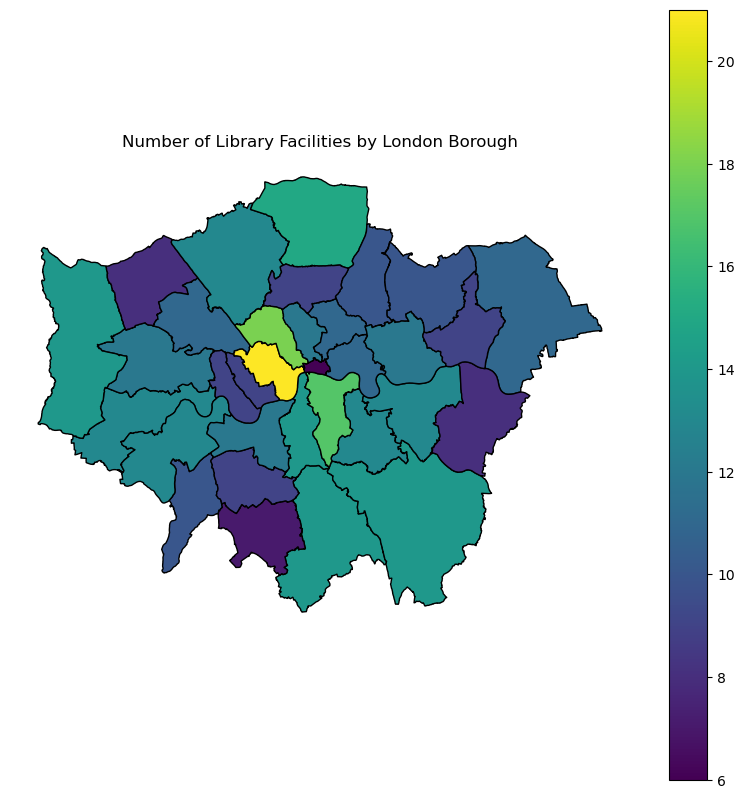

In [10]:
ax = boroughs_library.plot(
    column="library_count",
    figsize=(10, 10),
    legend=True,
    edgecolor="black"
)
ax.set_title("Number of Library Facilities by London Borough")
ax.set_axis_off()
plt.show()

The map above shows the total number of library facilities by borough. This provides an overview of the absolute distribution of libraries across London. Higher counts are visible in several central and inner London boroughs, while some outer boroughs show lower totals. However, a few outer boroughs still record moderate counts, suggesting that the pattern is uneven rather than simply central versus peripheral.

However, this measure reflects only the number of facilities and does not take account of differences in borough population size. As a result, raw counts alone cannot fully indicate whether library provision is relatively strong or weak from the perspective of residents.

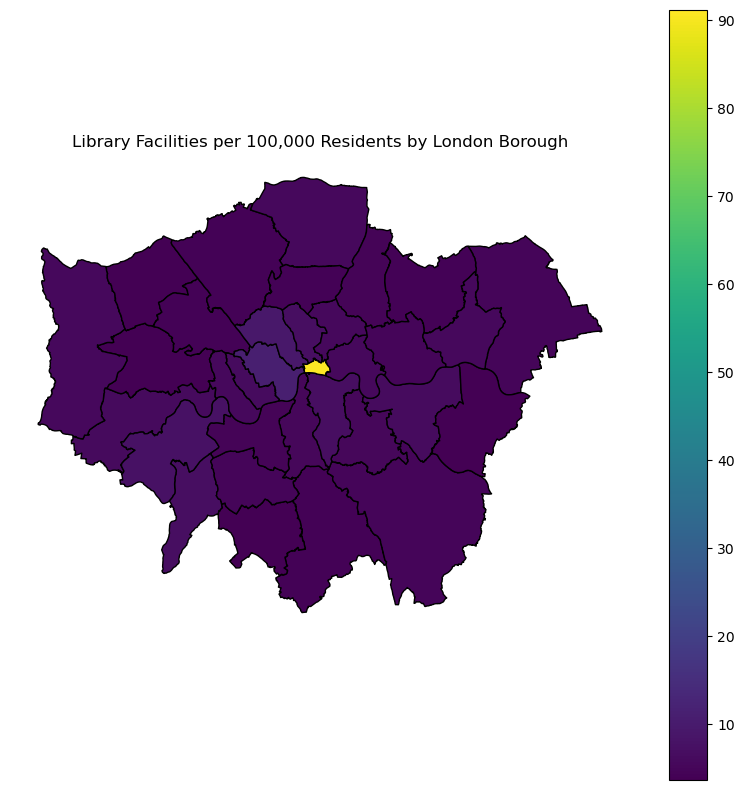

In [11]:
ax = boroughs_library.plot(
    column="library_per_100k",
    figsize=(10, 10),
    legend=True,
    edgecolor="black"
)
ax.set_title("Library Facilities per 100,000 Residents by London Borough")
ax.set_axis_off()
plt.show()

As the City of London has an exceptionally small resident population, its value is much higher than that of the other boroughs, and it dominates the colour scale of the standardised map. This makes it difficult to see variation across the rest of London, where most boroughs fall within a much narrower range. To improve the readability of the map, the City of London was excluded from the visualisation below so that the broader spatial pattern of library provision could be examined more clearly.

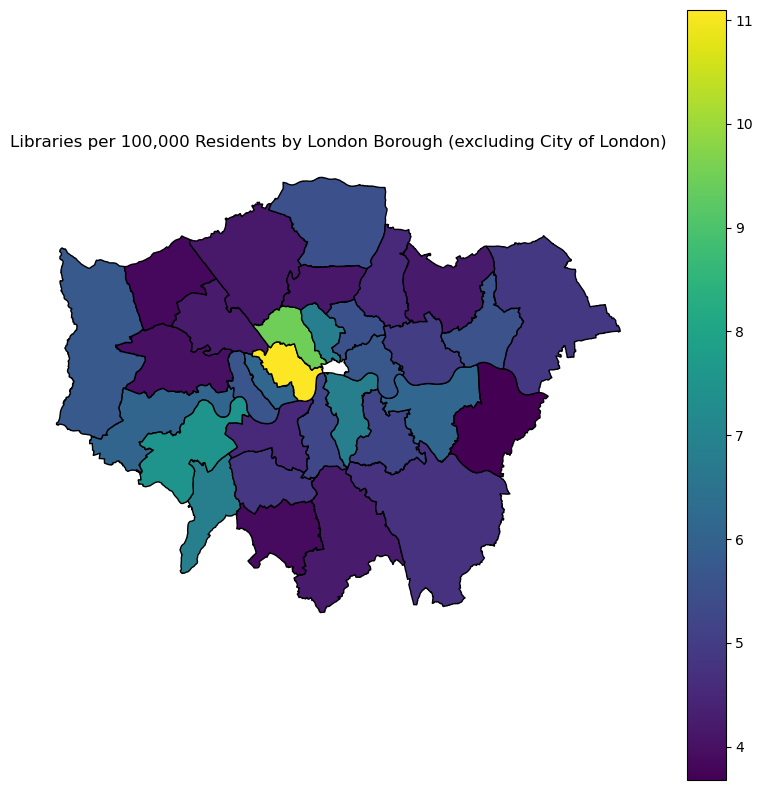

In [12]:
boroughs_library_no_city = boroughs_library[
    boroughs_library["name"] != "City of London"
].copy()

ax = boroughs_library_no_city.plot(
    column="library_per_100k",
    figsize=(10, 10),
    legend=True,
    edgecolor="black"
)
ax.set_title("Libraries per 100,000 Residents by London Borough (excluding City of London)")
ax.set_axis_off()
plt.show()

After excluding the City of London, variation in library provision across the remaining boroughs becomes much clearer. Relatively high levels of library provision per 100,000 residents can be seen in several inner and south-western boroughs. By contrast, a number of outer boroughs, particularly in the east and some parts of the north-west and south, show lower standardised values. The map also suggests that higher provision is not confined to the very centre, but extends into a small number of neighbouring boroughs.

Overall, the pattern suggests that library provision is uneven across London rather than evenly distributed. Some boroughs appear to have a stronger level of provision relative to their population size, while others appear comparatively less well served.

## 4. Pharmacy distribution analysis

### 4.1 Data Processing

Pharmacy data were obtained from OpenStreetMap using the tag 'amenity=pharmacy' for Greater London. The cleaning process followed the same general approach as the library analysis, but with criteria more suited to pharmacy records. Entries marked as 'dispensing = no' were removed, since the analysis focuses on facilities that provide dispensing services. Records with clearly abnormal values in the dispensing field were also excluded. In addition, possible duplicate records were checked using pharmacy postcode, and likely repeated entries were removed to reduce double counting and improve the reliability of the borough totals.

As in the previous section, the cleaned pharmacy dataset was converted into point locations and matched to London borough boundaries using a spatial join. Borough population data were then added so that the number of pharmacies per 100,000 residents could be calculated.

In [13]:
ox.settings.use_cache = True
ox.settings.log_console = True

place_name = "London, England, United Kingdom"
tags = {"amenity": "pharmacy"}

pharmacies = ox.features_from_place(place_name, tags)

pharmacy_cols = [
    c for c in [
        "name", "amenity", "dispensing", "healthcare",
        "operator", "brand", "addr:street", "addr:postcode", "geometry"
    ]
    if c in pharmacies.columns
]

pharmacies_clean = pharmacies[pharmacy_cols].copy()

In [14]:
pharmacies_cleaned = pharmacies_clean.copy()

pharmacies_cleaned = pharmacies_cleaned[
    pharmacies_cleaned["amenity"] == "pharmacy"
].copy()

pharmacies_cleaned = pharmacies_cleaned[
    pharmacies_cleaned.geometry.notnull()
].copy()

if "dispensing" in pharmacies_cleaned.columns:
    pharmacies_cleaned = pharmacies_cleaned[
        pharmacies_cleaned["dispensing"] != "no"
    ].copy()

if "dispensing" in pharmacies_cleaned.columns:
    pharmacies_cleaned = pharmacies_cleaned[
        ~pharmacies_cleaned["dispensing"].isin(["The Pestle & Mortar"])
    ].copy()

In [15]:
pharmacies_cleaned["name"] = pharmacies_cleaned["name"].where(
    pharmacies_cleaned["name"].isna(),
    pharmacies_cleaned["name"].astype(str).str.strip()
)

pharmacies_cleaned["addr:postcode"] = pharmacies_cleaned["addr:postcode"].where(
    pharmacies_cleaned["addr:postcode"].isna(),
    pharmacies_cleaned["addr:postcode"].astype(str).str.strip()
)

with_id = pharmacies_cleaned[
    pharmacies_cleaned["name"].notna() & pharmacies_cleaned["addr:postcode"].notna()
].copy()

without_id = pharmacies_cleaned[
    ~(pharmacies_cleaned["name"].notna() & pharmacies_cleaned["addr:postcode"].notna())
].copy()

with_id = with_id.drop_duplicates(subset=["name", "addr:postcode"])

pharmacies_cleaned = pd.concat([with_id, without_id], ignore_index=False)

In [16]:
pharmacies_geo = pharmacies_cleaned.copy()
pharmacies_geo["geometry_original"] = pharmacies_geo.geometry
pharmacies_geo["geometry"] = pharmacies_geo.geometry.representative_point()

In [17]:
boroughs = gpd.read_file("London_Boroughs.gpkg")

pharmacies_geo = pharmacies_geo.to_crs(boroughs.crs)

pharmacies_with_borough = gpd.sjoin(
    pharmacies_geo,
    boroughs[["name", "gss_code", "geometry"]],
    how="left",
    predicate="within"
)

In [18]:
pharmacy_counts = (
    pharmacies_with_borough
    .groupby("name_right")
    .size()
    .reset_index(name="pharmacy_count")
    .sort_values("pharmacy_count", ascending=False)
)

boroughs_pharmacy = boroughs.merge(
    pharmacy_counts,
    left_on="name",
    right_on="name_right",
    how="left"
)

boroughs_pharmacy["pharmacy_count"] = boroughs_pharmacy["pharmacy_count"].fillna(0)

In [19]:
pop_raw = pd.read_csv("borough_population_2025.csv")

pop = pop_raw[["Code", "Name", "Population"]].copy()
pop["Code"] = pop["Code"].astype(str).str.strip()
pop["Name"] = pop["Name"].astype(str).str.strip()
pop["Population"] = pd.to_numeric(pop["Population"], errors="coerce")

pop = pop.drop_duplicates(subset="Code", keep="first").copy()
pop = pop[pop["Code"].str.startswith("E09", na=False)].copy()

boroughs_pharmacy["gss_code"] = boroughs_pharmacy["gss_code"].astype(str).str.strip()

boroughs_pharmacy = boroughs_pharmacy.merge(
    pop,
    left_on="gss_code",
    right_on="Code",
    how="left"
)

boroughs_pharmacy["pharmacy_per_100k"] = (
    boroughs_pharmacy["pharmacy_count"] / boroughs_pharmacy["Population"] * 100000
)

In [20]:
print("Data quality checks for pharmacy dataset:")
print("Original pharmacy records:", len(pharmacies_clean))
print("Cleaned pharmacy records:", len(pharmacies_cleaned))
print("Unmatched pharmacy points after spatial join:", pharmacies_with_borough["name_right"].isna().sum())
print("Missing population values after merge:", boroughs_pharmacy["Population"].isna().sum())
print("Missing pharmacy_count values after merge:", boroughs_pharmacy["pharmacy_count"].isna().sum())

Data quality checks for pharmacy dataset:
Original pharmacy records: 1277
Cleaned pharmacy records: 1266
Unmatched pharmacy points after spatial join: 0
Missing population values after merge: 0
Missing pharmacy_count values after merge: 0


After cleaning, pharmacy records decreased slightly from 1,277 to 1,266. The spatial join produced no unmatched points, and the final borough-level table contains no missing values.

### 4.2 Visualising the distribution

In [21]:
pharmacy_rank = (
    boroughs_pharmacy[["name", "pharmacy_count", "Population", "pharmacy_per_100k"]]
    .sort_values("pharmacy_per_100k", ascending=False)
    .reset_index(drop=True)
)

pharmacy_rank.head(10)

,name,pharmacy_count,Population,pharmacy_per_100k
0,City of London,13,6581,197.538368
1,Westminster,93,189233,49.145762
2,Camden,58,190003,30.525834
3,Kensington and Chelsea,42,147678,28.440255
4,Newham,58,240517,24.114720
5,Richmond upon Thames,40,172782,23.150560
6,Tower Hamlets,43,193507,22.221418
7,Hammersmith and Fulham,34,160634,21.166129
8,Waltham Forest,44,221057,19.904369
9,Southwark,46,247853,18.559388


The table above shows the first ten boroughs in the ranking by pharmacies per 100,000 residents. Excluding the City of London, Westminster has the largest pharmacy count among the boroughs shown here. Camden, Kensington and Chelsea, and Richmond upon Thames also have relatively high population-adjusted values.

City of London is again different from the other boroughs in this measure. Its residents is very small, so the value per 100,000 residents is pushed up sharply and should be treated with caution.

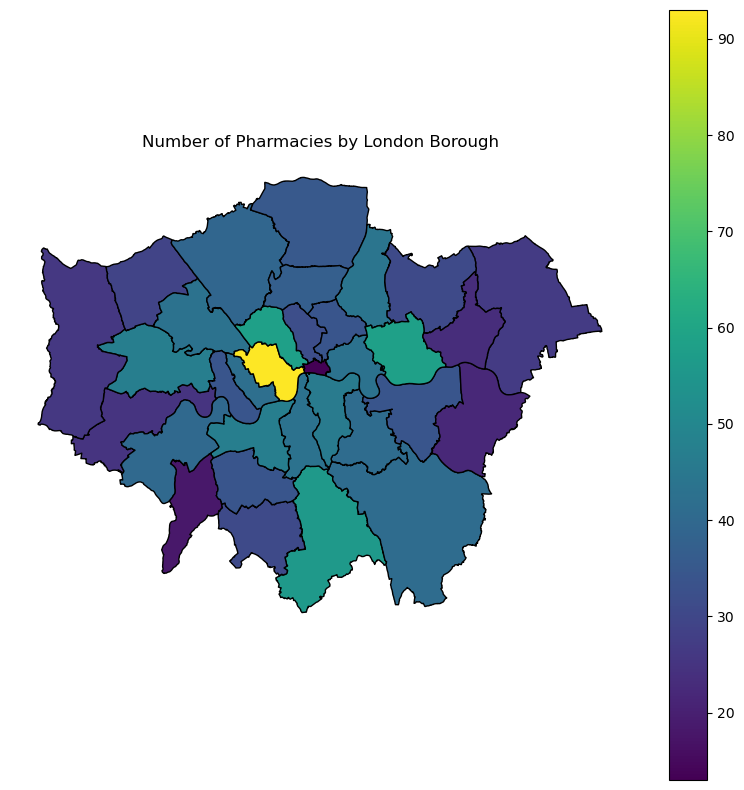

In [22]:
ax = boroughs_pharmacy.plot(
    column="pharmacy_count",
    figsize=(10, 10),
    legend=True,
    edgecolor="black"
)
ax.set_title("Number of Pharmacies by London Borough")
ax.set_axis_off()
plt.show()

The map above shows the total number of pharmacies in each London borough. In general, higher counts appear in some central and inner parts of London, while lower counts can be seen in a number of outer boroughs. Compared with the library map, pharmacies appear to be more numerous overall and more widely distributed across the city. Several outer boroughs still record moderate or relatively high totals, suggesting a broader spatial spread than that seen for libraries.

However, this map only shows absolute numbers. Boroughs with larger resident populations or stronger commercial activity may naturally contain more pharmacies, so this measure alone does not fully reflect relative provision. So population-standardised values are again needed to assess whether pharmacy access is stronger or weaker when differences in borough size are taken into account.


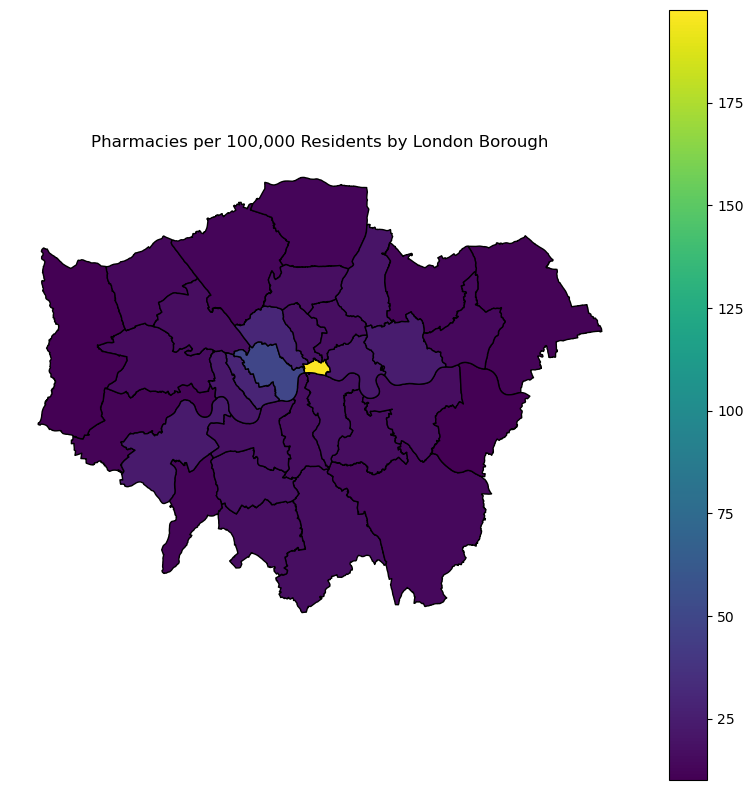

In [23]:
ax = boroughs_pharmacy.plot(
    column="pharmacy_per_100k",
    figsize=(10, 10),
    legend=True,
    edgecolor="black"
)
ax.set_title("Pharmacies per 100,000 Residents by London Borough")
ax.set_axis_off()
plt.show()

The population-standardised map shows the number of pharmacies per 100,000 residents. This gives a more comparable measure across boroughs, since it takes account of differences in population size. Compared with the map of raw counts, it provides a clearer indication of relative provision rather than overall facility totals. As in the library analysis, the City of London stands out as an extreme case. For the same reason, an additional map excluding the City of London is shown below so that variation across the remaining boroughs can be seen more clearly.

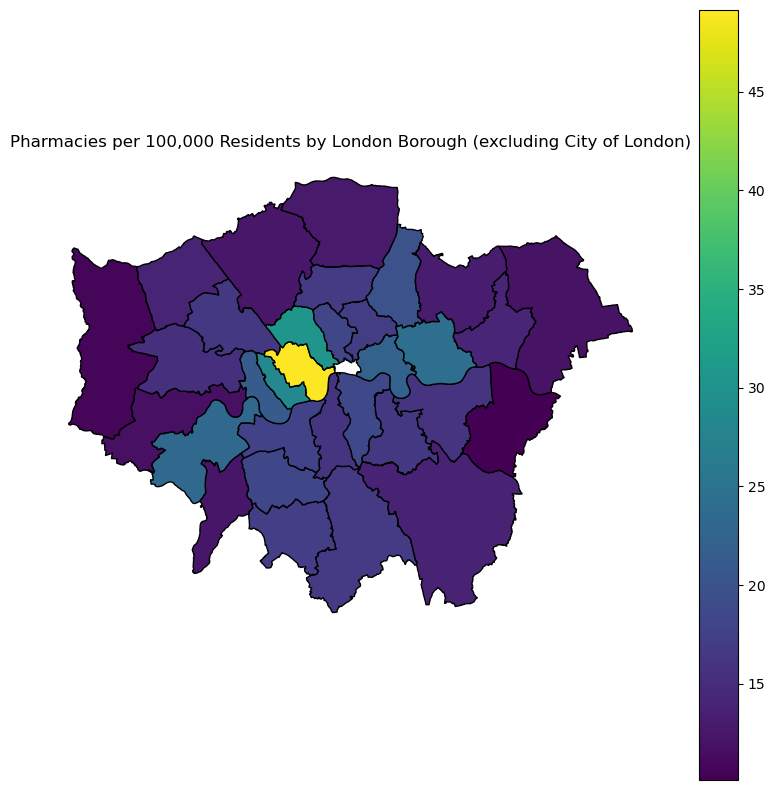

In [24]:
boroughs_pharmacy_no_city = boroughs_pharmacy[
    boroughs_pharmacy["name"] != "City of London"
].copy()

ax = boroughs_pharmacy_no_city.plot(
    column="pharmacy_per_100k",
    figsize=(10, 10),
    legend=True,
    edgecolor="black"
)
ax.set_title("Pharmacies per 100,000 Residents by London Borough (excluding City of London)")
ax.set_axis_off()
plt.show()

After excluding the City of London, the pattern across the remaining boroughs becomes easier to see. Relatively higher values appear in some central and inner parts of London, while several outer areas show lower levels of pharmacy provision per 100,000 residents. Even so, a number of outer and south-western boroughs still record moderate values, which suggests a broader spread than a simple centre–periphery pattern. Overall, the distribution is uneven, but pharmacies appear to be spread more widely across London than libraries, which may reflect the different service role of pharmacies within everyday healthcare provision.

## 5. Deprivation and facility provision analysis

### 5.1 Preparing the deprivation dataset

To examine whether borough-level deprivation is related to the distribution of library and pharmacy provision, IMD data were added to the borough summary dataset. The 2025 local authority IMD dataset was matched to London boroughs by borough code. Because lower IMD ranks indicate greater deprivation, a reversed deprivation measure was created so that higher values represent higher deprivation. This made the direction of later comparison easier to interpret. The deprivation data were then merged with the borough-level service provision table, creating a single dataset for descriptive and statistical analysis.

In [25]:
boroughs_analysis = boroughs_library.merge(
    boroughs_pharmacy[['gss_code', 'pharmacy_count', 'pharmacy_per_100k']],
    on='gss_code',
    how='left'
).copy()

In [26]:
imd = pd.read_csv("LA_LT_IMD2025_WGS84_-1477415534625908259.csv")

london_codes = boroughs_analysis[['gss_code']].drop_duplicates().copy()

imd_clean = imd[[
    'Local Authority Code (2024)',
    'Local Authority Name',
    'Rank of Average Rank'
]].copy()

imd_clean = imd_clean.rename(columns={
    'Local Authority Code (2024)': 'gss_code',
    'Local Authority Name': 'borough_name',
    'Rank of Average Rank': 'imd_rank'
})

imd_london = imd_clean.merge(
    london_codes,
    on='gss_code',
    how='inner'
)

max_rank = imd_london['imd_rank'].max()
imd_london['imd_deprivation'] = max_rank - imd_london['imd_rank']

analysis_table = boroughs_analysis[[
    'gss_code',
    'name',
    'Population',
    'library_per_100k',
    'pharmacy_per_100k'
]].copy()

analysis_table = analysis_table.merge(
    imd_london[['gss_code', 'imd_rank', 'imd_deprivation']],
    on='gss_code',
    how='left'
)

analysis_table['library_per_100k'] = analysis_table['library_per_100k'].round(2)
analysis_table['pharmacy_per_100k'] = analysis_table['pharmacy_per_100k'].round(2)

### 5.2 Borough-level deprivation summary

The table presents borough-level deprivation together with population-standardised library and pharmacy provision. It is ordered by deprivation, with more deprived boroughs shown first. This provides a descriptive overview of how deprivation, library provision and pharmacy provision appear alongside one another before the relationship is examined more directly using scatterplots and statistical tests.


In [27]:
deprivation_table = analysis_table[[
    'name',
    'Population',
    'imd_rank',
    'imd_deprivation',
    'library_per_100k',
    'pharmacy_per_100k'
]].sort_values(
    by='imd_deprivation',
    ascending=False
)

display(deprivation_table)

,name,Population,imd_rank,imd_deprivation,library_per_100k,pharmacy_per_100k
31,Newham,240517,7,275,4.99,24.11
32,Barking and Dagenham,162444,9,273,5.54,14.16
29,Hackney,199087,10,272,5.53,17.08
27,Tower Hamlets,193507,20,262,5.68,22.22
8,Brent,260317,22,260,4.23,16.52
30,Haringey,218559,29,253,4.12,16.93
13,Enfield,272731,37,245,5.50,12.83
28,Islington,175717,39,243,6.83,18.21
4,Ealing,302252,45,237,3.97,15.55
10,Lewisham,250310,46,236,5.19,16.38


The table shows that more deprived boroughs do not consistently have either higher or lower levels of library and pharmacy provision per 100,000 residents. Some highly deprived boroughs, such as Newham and Tower Hamlets, have relatively high pharmacy provision. While others, including Barking and Dagenham, record lower values. A similarly mixed pattern can be seen for libraries. For example, some more deprived boroughs such as Islington and Southwark show comparatively high library provision, whereas Brent and Ealing record lower population-adjusted values.

The contrast is also visible further down the table. Less deprived or more middle-ranking boroughs do not all cluster at either the high or low end of provision. Instead, relatively high values appear in a range of boroughs with different deprivation levels. As an initial descriptive comparison, the table suggests no consistent monotonic pattern between deprivation and provision.

### 5.3 Deprivation and provision scatterplots

Initial maps including all boroughs showed that the City of London was an extreme outlier. Because its resident population is exceptionally small, its values per 100,000 residents are inflated and compress the rest of the distribution. This makes the broader borough-level pattern difficult to interpret, particularly when most other boroughs fall within a much narrower range. For that reason, the main scatterplots below exclude the City of London so that variation across the remaining boroughs can be seen more clearly.
As noted above, the City of London was excluded because its unusually small resident population distorts per-capita values.

In [28]:
analysis_table_no_outlier = analysis_table[
    analysis_table['name'] != 'City of London'
].copy()

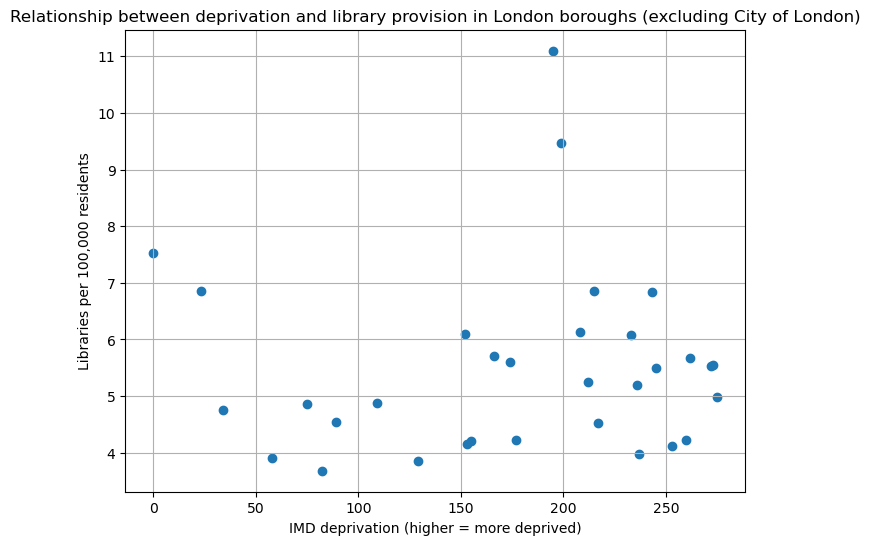

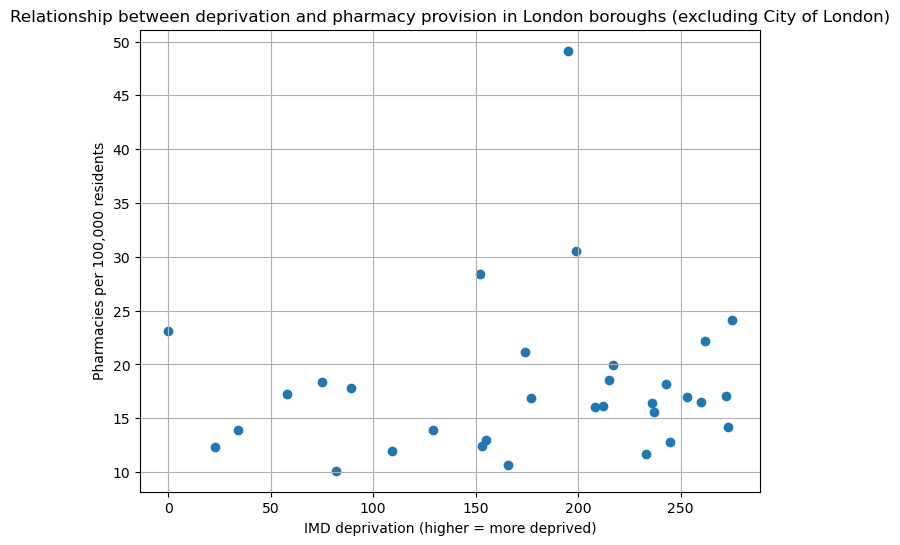

In [29]:
plt.figure(figsize=(8, 6))
plt.scatter(
    analysis_table_no_outlier['imd_deprivation'],
    analysis_table_no_outlier['library_per_100k']
)
plt.xlabel('IMD deprivation (higher = more deprived)')
plt.ylabel('Libraries per 100,000 residents')
plt.title('Relationship between deprivation and library provision in London boroughs (excluding City of London)')
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 6))
plt.scatter(
    analysis_table_no_outlier['imd_deprivation'],
    analysis_table_no_outlier['pharmacy_per_100k']
)
plt.xlabel('IMD deprivation (higher = more deprived)')
plt.ylabel('Pharmacies per 100,000 residents')
plt.title('Relationship between deprivation and pharmacy provision in London boroughs (excluding City of London)')
plt.grid(True)
plt.show()

The scatterplots show no obvious linear relationship between deprivation and the provision of either libraries or pharmacies. Library provision is spread across the deprivation range without a clear upward or downward trend, and boroughs with relatively high or low values appear at different points along the deprivation scale. Pharmacy provision also appears dispersed, with only a slight suggestion of higher values in some more deprived boroughs, though the pattern remains weak overall. Taken together, the plots suggest that deprivation alone does not produce a simple borough-level pattern in either type of provision.

### 5.4 Correlation and regression results

To examine the relationship more formally, Pearson correlation and simple linear regression were used. In both cases, deprivation was treated as the explanatory variable, while population-standardised library and pharmacy provision served as the outcome measures. These tests were used to assess whether the weak visual pattern seen in the scatterplots was reflected in the statistical results.


In [30]:
corr_library, p_library = pearsonr(
    analysis_table_no_outlier['imd_deprivation'],
    analysis_table_no_outlier['library_per_100k']
)

corr_pharmacy, p_pharmacy = pearsonr(
    analysis_table_no_outlier['imd_deprivation'],
    analysis_table_no_outlier['pharmacy_per_100k']
)

print("Library:  r =", round(corr_library, 3), ", p =", round(p_library, 4))
print("Pharmacy: r =", round(corr_pharmacy, 3), ", p =", round(p_pharmacy, 4))

Library:  r = 0.051 , p = 0.7834
Pharmacy: r = 0.119 , p = 0.5163


In [31]:
X = sm.add_constant(analysis_table_no_outlier['imd_deprivation'])

model_library = sm.OLS(
    analysis_table_no_outlier['library_per_100k'],
    X
).fit()

model_pharmacy = sm.OLS(
    analysis_table_no_outlier['pharmacy_per_100k'],
    X
).fit()

regression_summary = pd.DataFrame({
    'Model': ['Library provision', 'Pharmacy provision'],
    'Coefficient': [
        round(model_library.params['imd_deprivation'], 4),
        round(model_pharmacy.params['imd_deprivation'], 4)
    ],
    'p-value': [
        round(model_library.pvalues['imd_deprivation'], 4),
        round(model_pharmacy.pvalues['imd_deprivation'], 4)
    ],
    'R-squared': [
        round(model_library.rsquared, 3),
        round(model_pharmacy.rsquared, 3)
    ]
})

regression_summary

,Model,Coefficient,p-value,R-squared
0,Library provision,0.0010,0.7834,0.003
1,Pharmacy provision,0.0111,0.5163,0.014


The statistical results support the visual impression from the scatterplots. The correlation between deprivation and library provision is extremely weak (r = 0.051, p = 0.783), while the relationship between deprivation and pharmacy provision is also very weak (r = 0.119, p = 0.516). In both cases, the results are far from statistically significant, which suggests that there is no clear linear relationship at borough level.

The regression results point in the same direction. Deprivation explains very little of the variation in population-standardised provision, with R² values of 0.003 for libraries and 0.014 for pharmacies. The deprivation coefficient is positive in both models, but the effect is extremely small and not statistically significant. This means that increases in deprivation are not associated with a meaningful or reliable increase in either type of provision across London boroughs.


## 6. Discussion

The results suggest that borough-level deprivation is not closely associated with the per-capita distribution of either libraries or pharmacies in London. Although provision varies across boroughs, this variation does not follow a clear deprivation pattern. Some more deprived boroughs have relatively high pharmacy provision, while others do not, and the pattern for libraries is similarly uneven. At this scale, deprivation alone does not explain the geography shown in the results.

One possible reason is that the location of these facilities reflects more than deprivation alone. For libraries, current patterns may partly reflect earlier decisions about civic provision and local authority services (Department for Culture, Media and Sport, 2024). Pharmacies may be shaped not only by deprivation but also by patterns of demand and service use (Todd et al., 2014). This may help explain why pharmacies appear more widely distributed than libraries, even though neither shows a strong statistical relationship with deprivation.

The findings also point to the importance of spatial scale. Borough-level analysis is useful for comparing deprivation, population and service provision across London, but it remains a broad measure. A borough may appear reasonably served overall while still containing neighbourhoods with poorer access. In addition, facility counts provide only a partial picture of service access, since they do not capture distance, capacity, opening hours or actual use. For this reason, the results are better understood as a borough-level overview than as a detailed account of local accessibility.

Overall, no strong borough-level relationship was found between deprivation and the distribution of library and pharmacy provision in London. Differences in provision are still visible, but they are not closely aligned with deprivation in a simple way.

## 7. Limitations

Several limitations should be recognised. The analysis relies on OpenStreetMap data, and although the dataset was cleaned, some records may still be incomplete or inconsistently tagged. This means that a small number of library or pharmacy facilities may be missing or classified unevenly.

Libraries and pharmacies are also used here as examples of education-related and health-related local services, rather than as complete measures of those wider systems. The findings therefore apply to these two types of facilities only.

The borough scale provides a practical basis for comparison across London, but it may also hide variation within boroughs. In the same way, population-standardised measures improve comparability, yet resident population alone may not fully reflect wider patterns of service demand and use.

## 8. Conclusion

This study examined whether borough-level deprivation is related to the distribution of library and pharmacy provision in London. By combining facility location data, borough boundaries, population data and IMD measures, it compared both the absolute distribution and the per-capita provision of these two types of services across the city.

The results show that provision varies between boroughs, but no statistically significant borough-level relationship with deprivation was identified. This applies to both libraries and pharmacies. Deprivation therefore does not appear to be a strong predictor of per-capita provision at borough level, even though differences in service distribution remain visible across London.

From a policy perspective, the findings suggest that deprivation alone should not be used as a simple proxy for borough-level service provision. Future urban service planning should also consider factors such as daytime demand, transport accessibility, and local policy context. And further research could improve on this study by using smaller spatial units.

## 9. Word count

In [32]:
import io
import os
from nbformat import current

total_markdown = 0
total_heading = 0
total_code = 0

skip_reference = False

for root, dirs, files in os.walk("."):
    for file in files:
        if file.endswith(".ipynb") and not file.endswith("checkpoint.ipynb"):
            print(os.path.join(root, file))
            with io.open(os.path.join(root, file), 'r', encoding='utf-8') as f:
                nb = current.read(f, 'json')

            word_count_markdown = 0
            word_count_heading = 0
            word_count_code = 0
            skip_reference = False

            for cell in nb.worksheets[0].cells:
                if cell.cell_type in ["markdown", "heading"]:
                    source = cell['source'].strip()
                    if "reference" in source.lower() and ("#" in source or cell.cell_type == "heading"):
                        skip_reference = True
                        continue

                if skip_reference:
                    continue

                if cell.cell_type == "markdown":
                    words = cell['source'].replace('#', '').lstrip().split()
                    word_count_markdown += len(words)
                elif cell.cell_type == "heading":
                    words = cell['source'].replace('#', '').lstrip().split()
                    word_count_heading += len(words)
                elif cell.cell_type == "code":
                    words = cell['input'].replace('#', '').lstrip().split()
                    word_count_code += len(words)

            total_markdown += word_count_markdown
            total_heading += word_count_heading
            total_code += word_count_code
            print("{} Words in notebooks' markdown".format(word_count_markdown))
            print("{} Words in notebooks' heading".format(word_count_heading))
            print("{} Words in notebooks' code".format(word_count_code))
            print("")

./3149531_URBAN5123.ipynb
3005 Words in notebooks' markdown
50 Words in notebooks' heading
1030 Words in notebooks' code



/var/folders/_p/vz_9tj1s2xz5kt78qg0w761r0000gn/T/ipykernel_71986/3083498830.py:3: DeprecationWarning: nbformat.current is deprecated since before nbformat 3.0

- use nbformat for read/write/validate public API
- use nbformat.vX directly to composing notebooks of a particular version

  from nbformat import current


## 10. Reference list

Anderson, C. and Sharma, R. (2020) ‘Primary health care policy and vision for community pharmacy and pharmacists in England’, Pharmacy Practice, 18(1), p. 1870. Available at: https://doi.org/10.18549/PharmPract.2020.1.1870

Department for Culture, Media and Sport (2024) An independent review of English public libraries. London: Department for Culture, Media and Sport. Available at: https://www.gov.uk/government/publications/an-independent-review-of-english-public-libraries-report-and-government-reponse/an-independent-review-of-english-public-libraries

Greater London Authority (GLA) (n.d.) Land Area and Population Density, Ward and Borough. London Datastore. Available at: https://data.london.gov.uk/dataset/land-area-and-population-density-ward-and-borough-e1zp8/

Greater London Authority (GLA) (n.d.) London Boroughs. London Datastore. Available at: https://data.london.gov.uk/dataset/london-boroughs-e55pw/

Greater London Authority (n.d.) Population and household projections. London Datastore. Available at: https://data.london.gov.uk/demography/population-and-household-projections/ 

Klinenberg, E. (2018) Palaces for the people: How social infrastructure can help fight inequality, polarization, and the decline of civic life. New York: Crown. Available at: https://www.penguinrandomhouse.com/books/557044/palaces-for-the-people-by-eric-klinenberg/

Ministry of Housing, Communities and Local Government (2019) English indices of deprivation 2019. London: Ministry of Housing, Communities and Local Government. Available at: https://assets.publishing.service.gov.uk/media/5d8e26f6ed915d5570c6cc55/IoD2019_Statistical_Release.pdf 

Ministry of Housing, Communities and Local Government (MHCLG) GeoPortal (2025) Local Authority (Lower Tier) IMD2025 (WGS84). Available at: https://communitiesopendata-communities.hub.arcgis.com/datasets/5224907fd1b149458c840ebe5c977145_0/about

Rutter, P. and Barnes, N. (2024) ‘Facilitating self-care through community pharmacy in England’, Exploratory Research in Clinical and Social Pharmacy, 13, p. 100404. Available at: https://doi.org/10.1016/j.rcsop.2023.100404

Todd, A., Copeland, A., Husband, A., Kasim, A. and Bambra, C. (2014) ‘The positive pharmacy care law: an area-level analysis of the relationship between community pharmacy distribution, urbanity and social deprivation in England’, BMJ Open, 4(8), p. e005764. Available at: https://doi.org/10.1136/bmjopen-2014-005764

